In [1]:
!pip install tensorflow pandas scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("✅ Todo listo. TensorFlow versión:", tf.__version__)

✅ Todo listo. TensorFlow versión: 2.19.0


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Forma del dataset:", df.shape)
print("\n¿Cuántos se fueron vs se quedaron?")
print(df['Churn'].value_counts())
print("\nEn porcentaje:")
print(df['Churn'].value_counts(normalize=True).round(2) * 100)

Forma del dataset: (7043, 21)

¿Cuántos se fueron vs se quedaron?
Churn
No     5174
Yes    1869
Name: count, dtype: int64

En porcentaje:
Churn
No     73.0
Yes    27.0
Name: proportion, dtype: float64


In [4]:
df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Valores vacíos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna()

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("\n✅ Datos limpios. Filas restantes:", len(df))

Valores vacíos por columna:
TotalCharges    11
dtype: int64

✅ Datos limpios. Filas restantes: 7032


In [5]:
col_texto = df.select_dtypes(include='object').columns.tolist()
print("Columnas de texto:", col_texto)

df = pd.get_dummies(df, columns=col_texto, drop_first=True)

print("\n✅ Listo. Ahora tenemos", df.shape[1], "columnas (todo números)")
print("Primeras columnas:", df.columns[:8].tolist())

Columnas de texto: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Listo. Ahora tenemos 31 columnas (todo números)
Primeras columnas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes']


In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Tamaño de X: (7032, 30)
Tamaño de y: (7032,)

Datos de entrenamiento: (5625, 30)
Datos de prueba: (1407, 30)


In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Antes de normalizar, tenure iba de 0 a 72")
print("Después, los valores se ven así:")
print("Media:", X_train[:, 1].mean().round(4))
print("Desviación:", X_train[:, 1].std().round(4))
print("\n✅ Datos normalizados")

Antes de normalizar, tenure iba de 0 a 72
Después, los valores se ven así:
Media: -0.0
Desviación: 1.0

✅ Datos normalizados


In [8]:
model = keras.Sequential([


    layers.Dense(64, activation='relu', input_shape=(30,)),


    layers.Dropout(0.3),


    layers.Dense(32, activation='relu'),


    layers.Dropout(0.3),


    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1, 1: 2.7},
    verbose=1
)

print("\n✅ Entrenamiento terminado")

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6749 - loss: 0.8714 - val_accuracy: 0.7467 - val_loss: 0.5239
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7378 - loss: 0.7689 - val_accuracy: 0.7396 - val_loss: 0.5167
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7393 - loss: 0.7450 - val_accuracy: 0.7573 - val_loss: 0.4998
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7431 - loss: 0.7360 - val_accuracy: 0.7733 - val_loss: 0.4707
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7547 - loss: 0.7264 - val_accuracy: 0.7573 - val_loss: 0.5005
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7493 - loss: 0.7307 - val_accuracy: 0.7636 - val_loss: 0.4899
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7509 - loss: 0.7090 - val_accuracy: 0.7600 - val_loss: 0.4861
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7500 - loss: 0.7089 - val_accuracy:

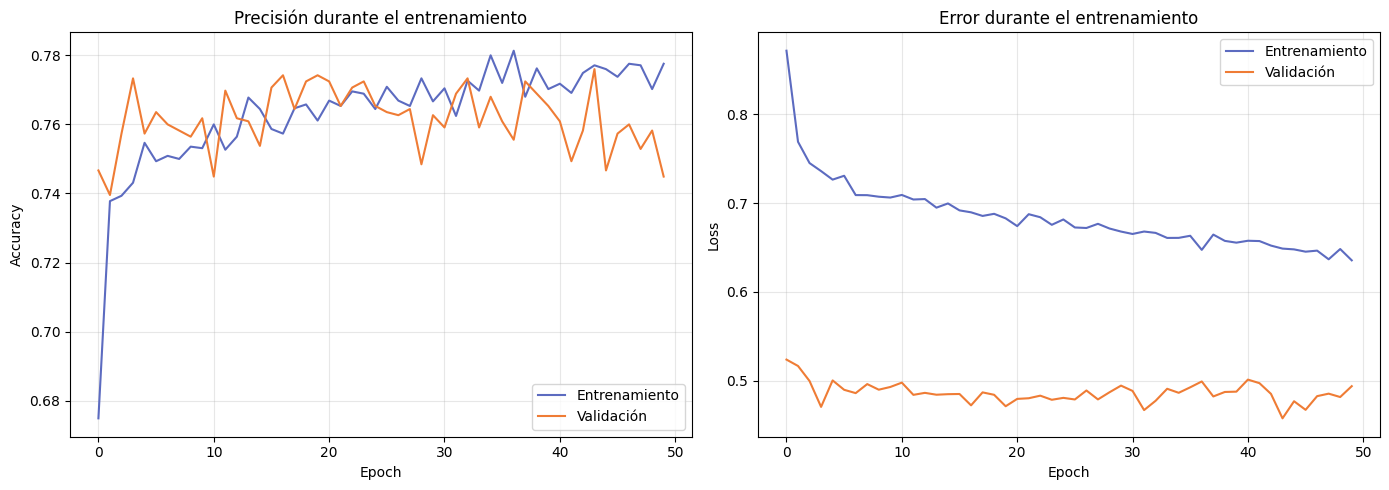

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Precisión
ax1.plot(history.history['accuracy'], label='Entrenamiento', color='#5C6BC0')
ax1.plot(history.history['val_accuracy'], label='Validación', color='#EF7C35')
ax1.set_title('Precisión durante el entrenamiento')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Error
ax2.plot(history.history['loss'], label='Entrenamiento', color='#5C6BC0')
ax2.plot(history.history['val_loss'], label='Validación', color='#EF7C35')
ax2.set_title('Error durante el entrenamiento')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== REPORTE DE CLASIFICACIÓN ===

              precision    recall  f1-score   support

    Se queda       0.90      0.71      0.80      1033
       Se va       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407



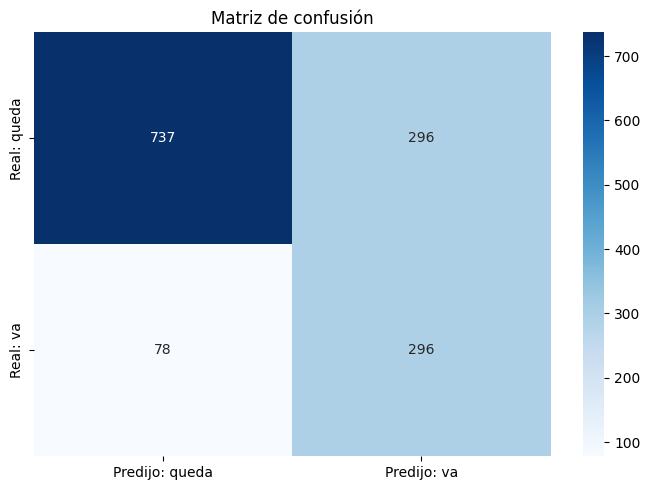

In [11]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("=== REPORTE DE CLASIFICACIÓN ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Se queda', 'Se va']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predijo: queda', 'Predijo: va'],
            yticklabels=['Real: queda', 'Real: va'])
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

In [12]:
import pickle

model.save('churn_model.keras')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("✅ Modelo guardado: churn_model.keras")
print("✅ Scaler guardado: scaler.pkl")
print("✅ Columnas guardadas: feature_names.pkl")
print("\nColumnas del modelo:", len(X.columns.tolist()))

✅ Modelo guardado: churn_model.keras
✅ Scaler guardado: scaler.pkl
✅ Columnas guardadas: feature_names.pkl

Columnas del modelo: 30


In [13]:
!pip install flask pyngrok --quiet

print("✅ Flask y ngrok listos")

✅ Flask y ngrok listos


In [16]:
!npm install -g localtunnel --quiet

import subprocess
import threading
import time

threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()
time.sleep(2)

result = subprocess.Popen(
    ['lt', '--port', '5000'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(3)
output = result.stdout.readline().decode()
print("🚀 URL pública:", output)

⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 1s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋ * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


🚀 URL pública: your url is: https://quiet-owls-sell.loca.lt



In [17]:
import requests

cliente_prueba = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
}

respuesta = requests.post(
    "https://quiet-owls-sell.loca.lt/predict",
    json=cliente_prueba
)

print("Respuesta de la API:")
print(respuesta.json())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


INFO:werkzeug:127.0.0.1 - - [16/Mar/2026 02:19:09] "POST /predict HTTP/1.1" 200 -


Respuesta de la API:
{'probabilidad_churn': 0.6911, 'resultado': 'Se va', 'riesgo': 'Medio'}
